> **Rama:** `feature/modeling`
>
> Continúa a partir de `feature/preprocessing` (necesita `X_train`, `y_train`, `preprocessor` ya definidos). Incluye el modelo baseline, la comparativa de algoritmos/balanceo y la optimización de hiperparámetros (`search`).

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from scipy.stats import loguniform


from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos y el preprocesador del paso anterior
_art_prep = joblib.load('src/artifacts/03_preprocessing.joblib')

X_train = _art_prep['X_train']
X_test = _art_prep['X_test']
y_train = _art_prep['y_train']
y_test = _art_prep['y_test']
preprocessor = _art_prep['preprocessor']
numeric_cols = _art_prep['numeric_cols']
nominal_cols = _art_prep['nominal_cols']
binary_cols = _art_prep['binary_cols']
RANDOM_STATE = _art_prep['RANDOM_STATE']

## **Paso 7: Modelo baseline**

Antes de comparar algoritmos necesitamos un suelo de referencia. Usamos un `DummyClassifier` que
siempre predice la clase mayoritaria (`Graduate`): cualquier modelo real tiene que superar claramente
este F1 macro para justificar su uso.

In [2]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipe = Pipeline([('pre', preprocessor), ('clf', DummyClassifier(strategy='most_frequent'))])
baseline_score = cross_validate(baseline_pipe, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()
print(f'Baseline (clase mayoritaria) — F1 macro (CV): {baseline_score:.3f}')

Baseline (clase mayoritaria) — F1 macro (CV): 0.222


## **Paso 8: Comparativa de modelos y estrategia de balanceo**

Comparamos varios algoritmos habituales para clasificación multiclase tabular, todos con
`class_weight='balanced'` cuando el algoritmo lo soporta (para compensar el desbalance moderado sin
generar datos sintéticos), evaluados con **validación cruzada estratificada (5 folds)** y **F1
macro**:

- Regresión Logística
- Random Forest
- Gradient Boosting
- Support Vector Classifier (SVC)

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)['test_score']
    results.append({'Modelo': name, 'F1 macro (media CV)': scores.mean(), 'Desv. típica': scores.std()})

results_df = pd.DataFrame(results).sort_values('F1 macro (media CV)', ascending=False).reset_index(drop=True)
results_df

,Modelo,F1 macro (media CV),Desv. típica
0,SVM (RBF),0.581174,0.016532
1,Logistic Regression,0.568732,0.023341
2,Random Forest,0.561320,0.014330
3,Gradient Boosting,0.538401,0.008634


C:\Users\anaco\AppData\Local\Temp\ipykernel_20476\2592844925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='F1 macro (media CV)', y='Modelo', ax=ax, palette='viridis')


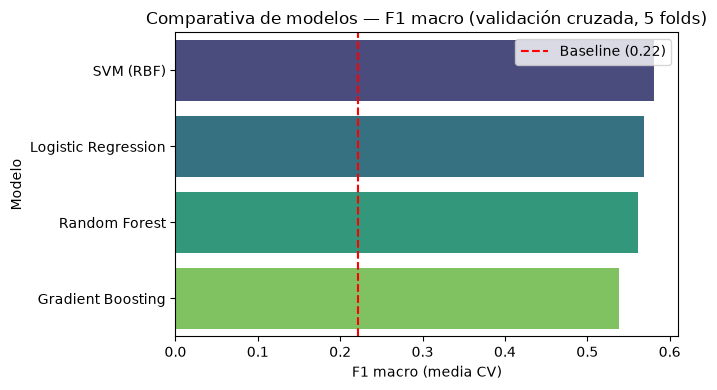

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=results_df, x='F1 macro (media CV)', y='Modelo', ax=ax, palette='viridis')
ax.axvline(baseline_score, color='red', linestyle='--', label=f'Baseline ({baseline_score:.2f})')
ax.set_title('Comparativa de modelos — F1 macro (validación cruzada, 5 folds)')
ax.legend()
plt.tight_layout()
plt.show()

**Estrategia de balanceo — `class_weight` vs SMOTE.** Todos los modelos anteriores ya usan
`class_weight='balanced'`. Comprobamos si sobremuestrear artificialmente con **SMOTE** mejora el
resultado sobre el mejor modelo lineal, para decidir con qué estrategia nos quedamos.

In [5]:
best_model_name = results_df.iloc[0]['Modelo']
print(f'Mejor modelo en la comparativa: {best_model_name}')

pipe_class_weight = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])
score_cw = cross_validate(pipe_class_weight, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()

pipe_smote = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])
score_smote = cross_validate(pipe_smote, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()

print(f'F1 macro con class_weight=\"balanced\": {score_cw:.3f}')
print(f'F1 macro con SMOTE:                  {score_smote:.3f}')

Mejor modelo en la comparativa: SVM (RBF)
F1 macro con class_weight="balanced": 0.569
F1 macro con SMOTE:                  0.571


SMOTE no aporta una mejora relevante sobre `class_weight='balanced'` (diferencia dentro del
ruido de la validación cruzada). Nos quedamos con **`class_weight='balanced'`** como estrategia de
balanceo: es más simple, no genera observaciones sintéticas (evita el riesgo de sobreajustar a
vecinos artificiales en variables categóricas de alta cardinalidad tras el one-hot) y da resultados
equivalentes.

En la comparativa de modelos, **SVM y Logistic Regression** obtienen el mejor F1 macro, muy por
encima del resto y del baseline. Elegimos **Logistic Regression** como candidato principal a afinar:
su rendimiento es prácticamente idéntico al de SVM, pero es más rápida de entrenar/tunear y, sobre
todo, mucho más interpretable (coeficientes directamente relacionables con cada variable), algo muy
valioso para el caso de uso — el equipo de orientación académica necesita entender *por qué* un
estudiante está en riesgo, no solo la predicción.

## **Paso 9: Optimización de hiperparámetros**

Afinamos la Regresión Logística con `RandomizedSearchCV`, optimizando **F1 macro** mediante
validación cruzada estratificada (5 folds), buscando la fuerza de regularización óptima.

In [6]:
param_dist = {
    'clf__C': loguniform(1e-3, 1e2),
}

final_pipe_search = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])

search = RandomizedSearchCV(
    final_pipe_search,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
search.fit(X_train, y_train)

print(f'Mejor F1 macro (CV): {search.best_score_:.3f}')
print(f'Mejores hiperparámetros: {search.best_params_}')

Mejor F1 macro (CV): 0.575
Mejores hiperparámetros: {'clf__C': np.float64(0.19069966103000435)}


In [7]:
# Guardar el objeto de búsqueda y los sets de validación/columnas
joblib.dump({
    'search': search,
    'X_test': X_test,
    'y_test': y_test,
    'numeric_cols': numeric_cols,
    'nominal_cols': nominal_cols,
    'binary_cols': binary_cols
}, 'src/artifacts/04_modeling.joblib')
print("Modelado guardado exitosamente.")

Modelado guardado exitosamente.
